# Non-Uniform Azimuthal Poisson Solver: $N$ vs. $M$ Analysis & Disk Error Comparisons

This notebook evaluates the **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT** solvers on a disk $\mathcal{B}(0, R)$ for a Poisson problem with a localized high-frequency azimuthal wave packet:
$$
u(r, \theta) = r^2 \left(R^2 - r^2\right) \frac{\cos(k \theta)}{1 - \gamma \cos(\theta - \theta_0)}
$$
with $k=4$, sharpness $\gamma = 0.65$, and homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.paper.helpers import (
    get_azimuthal_benchmark_problem,
    generate_adapted_clustered_azimuthal,
    run_benchmark_case,
    run_all_algorithms_NxM_study,
    render_algorithm_tables,
    plot_solution_and_grids,
    plot_accuracy_and_runtimes_from_df,
    plot_3x3_disk_error_comparison,
    plot_adapted_vs_highres_uniform
)

# =========================================================================
# Configurable Problem & Grid Parameters
# =========================================================================
R = 1.0                     # Disk radius
THETA_0 = np.pi             # Center angle of localized feature (radians)
K_MODE = 4                  # Azimuthal wave frequency
GAMMA = 0.65                # Angular sharpness parameter in [0, 1)

# Solver & Radial Grid Settings
QUAD_RULE = 2               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann
CLUSTER_STRENGTH = 0.40     # Angular clustering factor in [0, 1)

# N vs M Sweep Grids
N_VALUES = [16, 24, 32, 48, 64, 128]
M_VALUES = [16, 32, 64, 128, 256]

# High-Resolution Uniform Comparison Settings
N_LOW_ADAPT = 32
N_HIGH_UNIFORM = 256
M_FIXED_PLOTS = 64

C:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

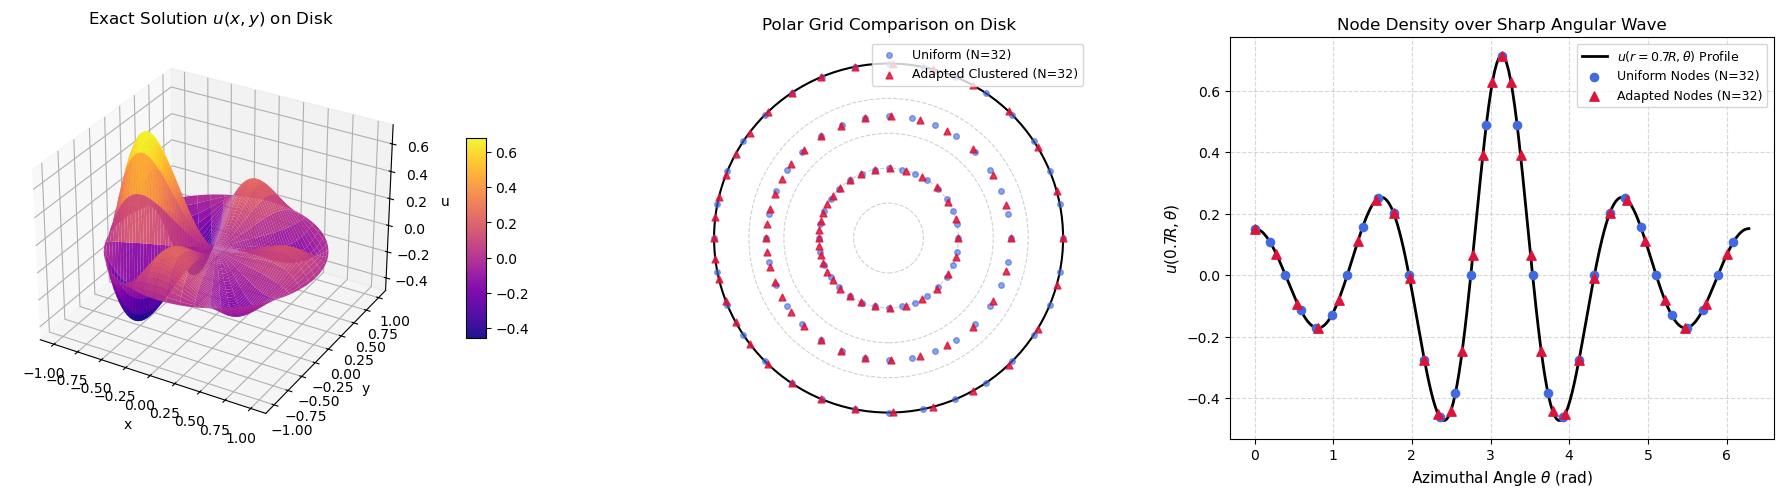

In [2]:
# Construct benchmark problem
problem = get_azimuthal_benchmark_problem(
    R=R, theta_0=THETA_0, k_mode=K_MODE, gamma=GAMMA
)

# Visualize 3D solution surface and 2D polar lattice
plot_solution_and_grids(
    problem=problem,
    N_adapt=32,
    N_unif=32,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [3]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE
)

Computing N vs M Grid Matrix:   0%|          | 0/90 [00:00<?, ?it/s]

Computing N vs M Grid Matrix:   1%|          | 1/90 [00:00<00:13,  6.61it/s]

Computing N vs M Grid Matrix:   3%|▎         | 3/90 [00:00<00:06, 12.89it/s]

Computing N vs M Grid Matrix:   6%|▌         | 5/90 [00:00<00:06, 13.33it/s]

Computing N vs M Grid Matrix:   8%|▊         | 7/90 [00:00<00:10,  7.76it/s]

...

Computing N vs M Grid Matrix:  69%|██████▉   | 62/90 [00:05<00:01, 20.52it/s]

Computing N vs M Grid Matrix:  78%|███████▊  | 70/90 [00:05<00:00, 30.46it/s]

Computing N vs M Grid Matrix:  88%|████████▊ | 79/90 [00:05<00:00, 41.92it/s]

Computing N vs M Grid Matrix:  94%|█████████▍| 85/90 [00:05<00:00, 44.75it/s]

Computing N vs M Grid Matrix: 100%|██████████| 90/90 [00:05<00:00, 15.02it/s]

## 4. $L_2$ Error & Runtime Tables ($N$ vs. $M$)
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [4]:
# Relative L2 Error Tables for each algorithm
error_tables = render_algorithm_tables(df_results, value_col="L2_rel", format_sci=True)

# Runtime (seconds) Tables for each algorithm
runtime_tables = render_algorithm_tables(df_results, value_col="runtime", format_sci=False)


Adapted NUFFT — Relative L₂ Error (N vs M)


M,16,32,64,128,256
N,,,,,
16,3.39e-01,3.40e-01,3.40e-01,3.40e-01,3.40e-01
24,2.80e-02,2.83e-02,2.84e-02,2.84e-02,2.84e-02
32,3.64e-03,3.10e-03,3.10e-03,3.10e-03,3.10e-03
48,2.12e-03,2.38e-04,2.84e-05,4.92e-06,3.55e-06
64,2.13e-03,2.78e-04,1.85e-02,9.33e-03,1.85e-02
128,2.14e-03,3.21e-04,8.42e-02,4.74e-01,2.01e+01



Adapted NUDFT — Relative L₂ Error (N vs M)


M,16,32,64,128,256
N,,,,,
16,3.39e-01,3.40e-01,3.40e-01,3.40e-01,3.40e-01
24,2.80e-02,2.83e-02,2.84e-02,2.84e-02,2.84e-02
32,3.64e-03,3.10e-03,3.10e-03,3.10e-03,3.10e-03
48,2.13e-03,2.42e-04,5.01e-05,4.16e-05,4.15e-05
64,2.12e-03,2.38e-04,2.82e-05,3.47e-06,7.33e-07
128,2.12e-03,2.38e-04,2.82e-05,3.42e-06,4.25e-07



Uniform FFT — Relative L₂ Error (N vs M)


...

M,16,32,64,128,256
N,,,,,
16,0.1468,0.0430,0.0486,0.0425,0.0618
24,0.3210,0.0738,0.0803,0.1175,0.1352
32,0.1713,0.0533,0.0559,0.0457,0.0579
48,0.4355,0.0778,0.0886,0.0831,0.1079
64,0.2333,0.0599,0.1226,0.0753,0.1746
128,0.3955,0.0841,0.1718,0.1884,0.3615



Adapted NUDFT — Runtime (s) (N vs M)


M,16,32,64,128,256
N,,,,,
16,0.0051,0.0050,0.0078,0.0105,0.0176
24,0.0049,0.0060,0.0084,0.0117,0.0208
32,0.0035,0.0038,0.0046,0.0074,0.0142
48,0.0069,0.0086,0.0086,0.0183,0.0270
64,0.0051,0.0072,0.0107,0.0183,0.0245
128,0.0627,0.0737,0.0797,0.0703,0.0889



Uniform FFT — Runtime (s) (N vs M)


M,16,32,64,128,256
N,,,,,
16,0.0030,0.0014,0.0031,0.0016,0.0026
24,0.0024,0.0018,0.0022,0.0026,0.0027
32,0.0021,0.0016,0.0018,0.0019,0.0033
48,0.0021,0.0019,0.0041,0.0027,0.0059
64,0.0020,0.0017,0.0022,0.0026,0.0047
128,0.0018,0.0022,0.0032,0.0055,0.0082


## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

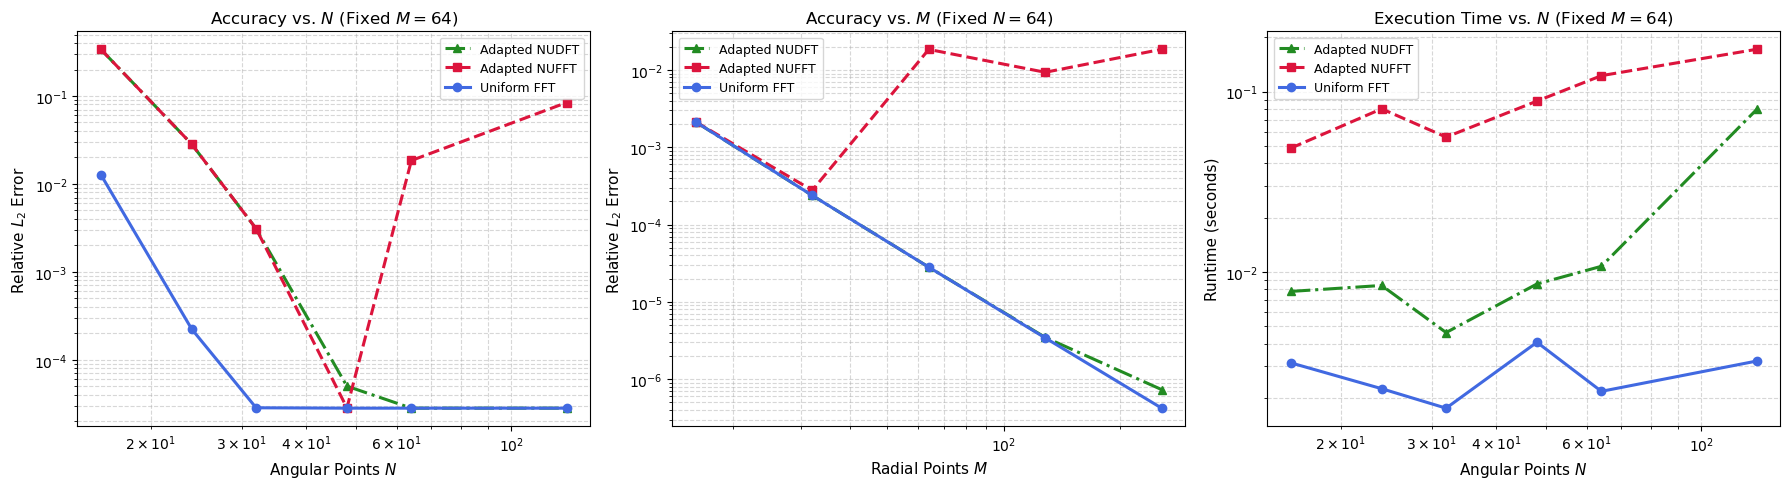

In [5]:
plot_accuracy_and_runtimes_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 6. $3 \times 3$ Disk Error Comparison (Equal Resolution)
3D pointwise error surfaces on the disk at equal resolutions across:
- **Rows:** $N = 32, 64, 128$
- **Columns:** Adapted NUFFT | Adapted NUDFT | Uniform FFT

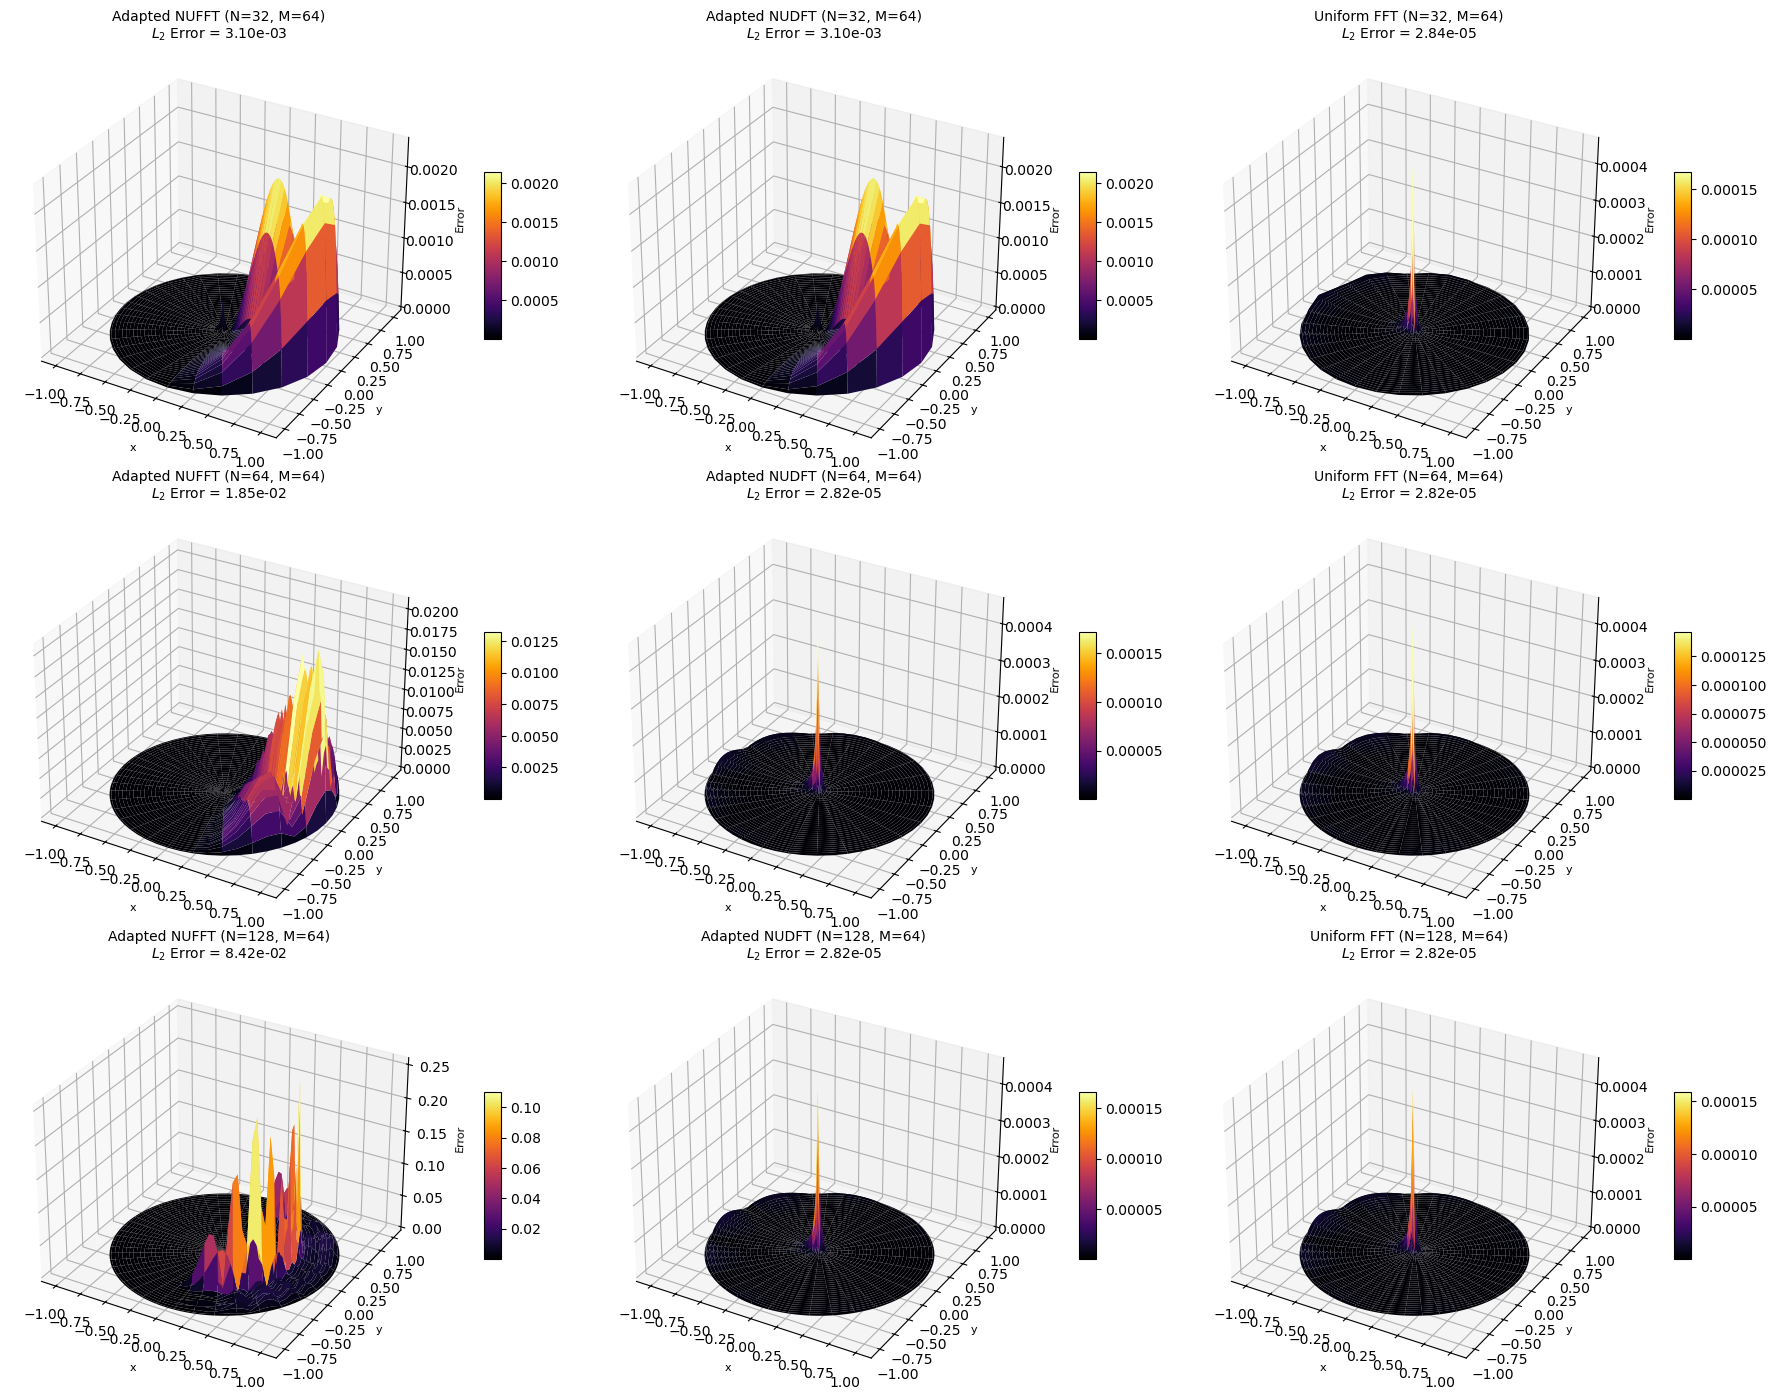

In [6]:
plot_3x3_disk_error_comparison(
    problem=problem,
    N_list=[32, 64, 128],
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).

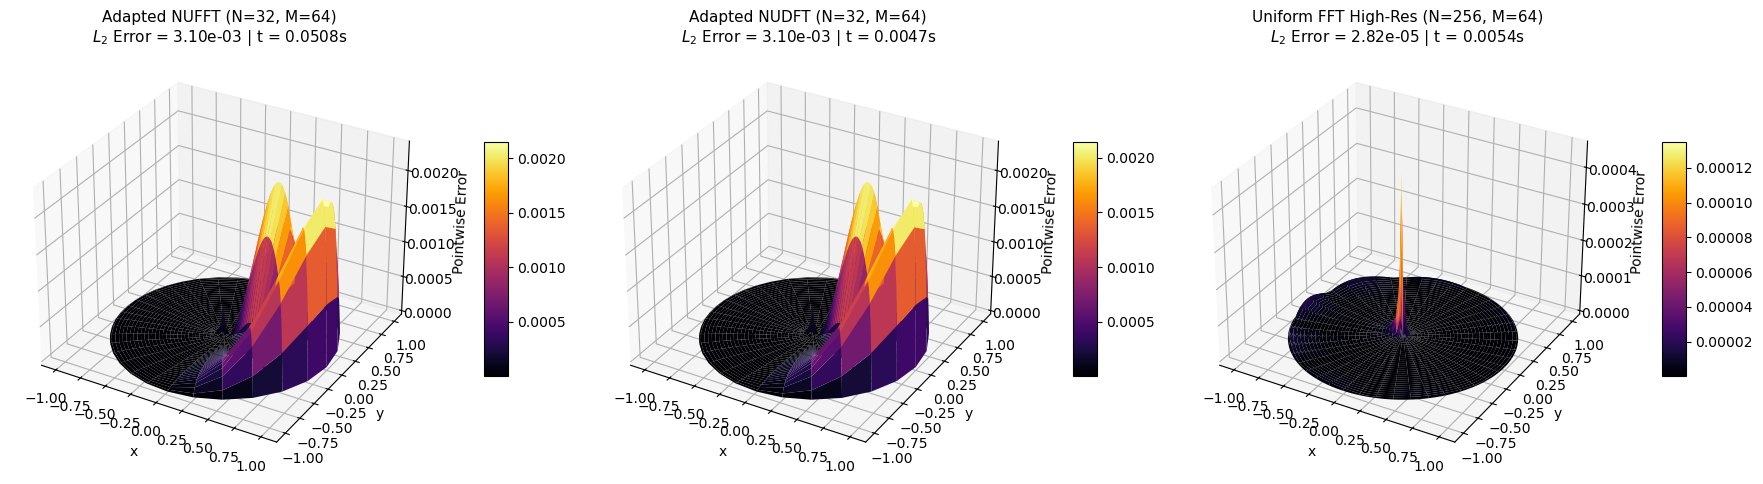

In [7]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)